# ERCS Experiment Report
## Emergency Response Coordination Simulator
### Adaptive vs Baseline Coordination Under Intermittent Connectivity

MSc Computer Science — University of Liverpool, 2026

This notebook runs the complete ERCS experiment and produces publication-quality
visualizations and statistical analysis for the dissertation.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure src is on the path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from ercs.config.parameters import AlgorithmType, SimulationConfig
from ercs.evaluation.metrics import MetricType, PerformanceEvaluator
from ercs.simulation.engine import ExperimentRunner
from ercs.visualization.plots import (
    METRICS_CONFIG,
    apply_thesis_style,
    build_anova_table,
    build_parameter_tables,
    build_results_dataframe,
    build_ttest_table,
    compute_summary_stats,
    plot_box_distributions,
    plot_degradation_lines,
    plot_grouped_bars,
    plot_heatmap,
    save_figure,
)

apply_thesis_style()
FIGURES_DIR = project_root / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Experiment Parameters

All parameters are sourced from published literature and configured
in `configs/default.yaml`.

In [2]:
config = SimulationConfig()

tables = build_parameter_tables(config)
for name, table_df in tables.items():
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    display(table_df.style.hide(axis="index"))


  Network Topology


Parameter,Value,Source
Node count,50 (2 coordination + 48 mobile),Ullah & Qayyum (2022)
Simulation area,3000 x 1500 m²,Ullah & Qayyum (2022)
Incident zone,700 x 600 m²,Ullah & Qayyum (2022)
Radio range,100 m,Ullah & Qayyum (2022)
Buffer size,5 MB,Ullah & Qayyum (2022)
Message size,512 kB,Kumar et al. (2023)
Connectivity scenarios,"75%, 40%, 20%",Karaman et al. (2026)
Mobility model,Random Waypoint,Ullah & Qayyum (2022)
Speed range,0–20 m/s,Ullah & Qayyum (2022)



  PRoPHET Protocol


Parameter,Value,Source
P_init,0.75,Kumar et al. (2023)
β (transitivity),0.25,Kumar et al. (2023)
γ (aging),0.98,Kumar et al. (2023)
Message TTL,300 min,Ullah & Qayyum (2022)
Transmit speed,2 Mbps,Ullah & Qayyum (2022)
Buffer drop policy,Drop Oldest,Ullah & Qayyum (2022)



  Scenario Generation


Parameter,Value,Source
Task arrival,Poisson,Pu et al. (2025)
Message rate,2.0 msgs/min,Kumar et al. (2023)
Urgency distribution,20% H / 50% M / 30% L,Li et al. (2025)
Simulation duration,43200 s (720 min),Ullah & Qayyum (2022)
Runs per configuration,30,Law (2015)



  Coordination


Parameter,Value,Source
Update interval,30 min,Kaji et al. (2025)
Priority levels,3,Rosas et al. (2023)
Path threshold,P > 0.0,Ullah & Qayyum (2022)
Adaptive ordering,Urgency First,Kaji et al. (2025)
Baseline ordering,FCFS,Design decision


In [3]:
connectivity_levels = config.network.connectivity_scenarios
runs_per_config = config.scenario.runs_per_configuration

print("Experimental Design")
print("=" * 40)
print(f"  Algorithms:          2 (Adaptive, Baseline)")
print(f"  Connectivity levels: {len(connectivity_levels)} ({', '.join(f'{c*100:.0f}%' for c in connectivity_levels)})")
print(f"  Runs per config:     {runs_per_config}")
print(f"  Total runs:          {config.total_experimental_runs}")
print(f"  Sim duration:        {config.scenario.simulation_duration_seconds}s ({config.scenario.simulation_duration_seconds // 60} min)")

Experimental Design
  Algorithms:          2 (Adaptive, Baseline)
  Connectivity levels: 3 (75%, 40%, 20%)
  Runs per config:     30
  Total runs:          180
  Sim duration:        43200s (720 min)


## 2. Experiment Execution

Running all 180 simulations (2 algorithms x 3 connectivity levels x 30 runs).

> To run a quick test, change `runs_per_config` below to `5`.

In [4]:
from IPython.display import clear_output

# Change to 5 for a quick test
#RUNS = runs_per_config
RUNS = 5


runner = ExperimentRunner(config=config, base_seed=42)
algorithms = [AlgorithmType.ADAPTIVE, AlgorithmType.BASELINE]
total = len(algorithms) * len(connectivity_levels) * RUNS
start_time = time.time()


def progress_callback(current, total_runs):
    clear_output(wait=True)
    pct = current / total_runs * 100
    bar_len = 40
    filled = int(bar_len * current // total_runs)
    bar = "=" * filled + ">" + " " * max(0, bar_len - filled - 1)
    elapsed = time.time() - start_time
    eta = (elapsed / current) * (total_runs - current) if current > 0 else 0

    alg_idx = (current - 1) // (len(connectivity_levels) * RUNS)
    remainder = (current - 1) % (len(connectivity_levels) * RUNS)
    conn_idx = remainder // RUNS
    run_idx = remainder % RUNS

    alg_name = algorithms[alg_idx].value.capitalize()
    conn_pct = f"{connectivity_levels[conn_idx] * 100:.0f}%"

    print(f"ERCS Experiment Progress")
    print(f"[{bar}] {current}/{total_runs} ({pct:.1f}%)")
    print(f"Current: {alg_name} @ {conn_pct} connectivity, run {run_idx + 1}/{RUNS}")
    print(f"Elapsed: {elapsed:.0f}s | ETA: {eta:.0f}s")


results = runner.run_all(
    algorithms=algorithms,
    connectivity_levels=connectivity_levels,
    runs_per_config=RUNS,
    progress_callback=progress_callback,
)

clear_output(wait=True)
elapsed_total = time.time() - start_time
print(f"Experiment complete: {len(results)} runs in {elapsed_total:.1f}s")
print(f"Average time per run: {elapsed_total / len(results):.2f}s")

Experiment complete: 30 runs in 5987.0s
Average time per run: 199.57s


In [5]:
df = build_results_dataframe(results)
print(f"Results DataFrame: {df.shape[0]} rows x {df.shape[1]} columns\n")
display(
    df.groupby(["algorithm", "connectivity"])[["delivery_rate", "assignment_rate", "avg_response_time"]]
    .describe()
    .round(4)
)

Results DataFrame: 30 rows x 12 columns



delivery_rate                                          \
                               count    mean     std     min     25%     50%   
algorithm connectivity                                                         
adaptive  0.20                   5.0  0.0437  0.0156  0.0212  0.0345  0.0497   
          0.40                   5.0  0.1438  0.2801  0.0000  0.0110  0.0300   
          0.75                   5.0  0.4250  0.4665  0.0368  0.0910  0.3324   
baseline  0.20                   5.0  0.1213  0.1311  0.0103  0.0221  0.0462   
          0.40                   5.0  0.1838  0.1188  0.0421  0.0889  0.2182   
          0.75                   5.0  0.1856  0.1056  0.0234  0.1514  0.1988   

                                       assignment_rate          ...          \
                           75%     max           count    mean  ...     75%   
algorithm connectivity                                          ...           
adaptive  0.20          0.0538  0.0594             5.0  0.8105  ...  0.9552   
          0.40          0.0338  0.6443             5.0  0.7663  ...  0.8813   
          0.75          0.4666  1.1982             5.0  0.8817  ...  1.0000   
baseline  0.20          0.2517  0.2762             5.0  1.0000  ...  1.0000   
          0.40          0.2317  0.3383             5.0  1.0000  ...  1.0000   
          0.75          0.2681  0.2865             5.0  1.0000  ...  1.0000   

                            avg_response_time                        \
                        max             count       mean        std   
algorithm connectivity                                                
adaptive  0.20          1.0               5.0  5077.8369  1279.4469   
          0.40          1.0               5.0  7463.3916  3206.5567   
          0.75          1.0               5.0  5911.5143  2399.0684   
baseline  0.20          1.0               5.0   905.2560    14.7335   
          0.40          1.0               5.0   904.4852     8.0989   
          0.75          1.0               5.0   904.2370    11.6294   

                                                                                
                              min        25%        50%        75%         max  
algorithm connectivity                                                          
adaptive  0.20          3066.1316  4923.0617  5097.3183  5858.2142   6444.4587  
          0.40          3862.8716  4691.9736  8496.4087  8525.9358  11739.7681  
          0.75          3239.6977  5078.2540  5615.7743  5827.1526   9796.6926  
baseline  0.20           881.3353   903.9918   907.0816   913.9066    919.9647  
          0.40           899.4194   899.7003   900.5340   904.2111    918.5609  
          0.75           886.2008   899.2620   910.0842   910.6480    914.9900  

[6 rows x 24 columns]

## 3. Results Visualization

All figures use a consistent colour scheme:
- **Adaptive** (blue): Network-aware, urgency-first coordination
- **Baseline** (red): Proximity-only, FCFS coordination

In [6]:
# Precompute summary statistics for all metrics
summaries = {}
for metric_key in METRICS_CONFIG:
    summaries[metric_key] = compute_summary_stats(df, metric_key)

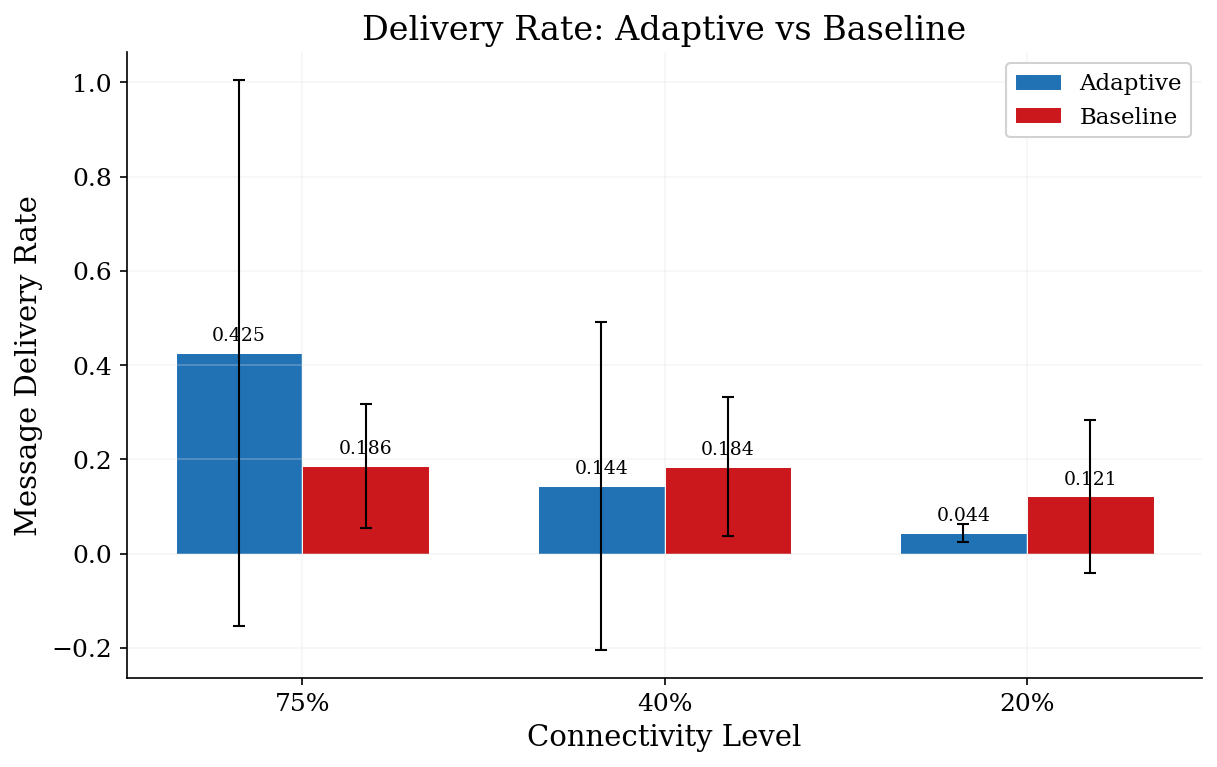

In [7]:
# Figure 1: Delivery Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["delivery_rate"], "delivery_rate")
save_figure(fig, "fig_delivery_rate_bars", FIGURES_DIR)
plt.show()

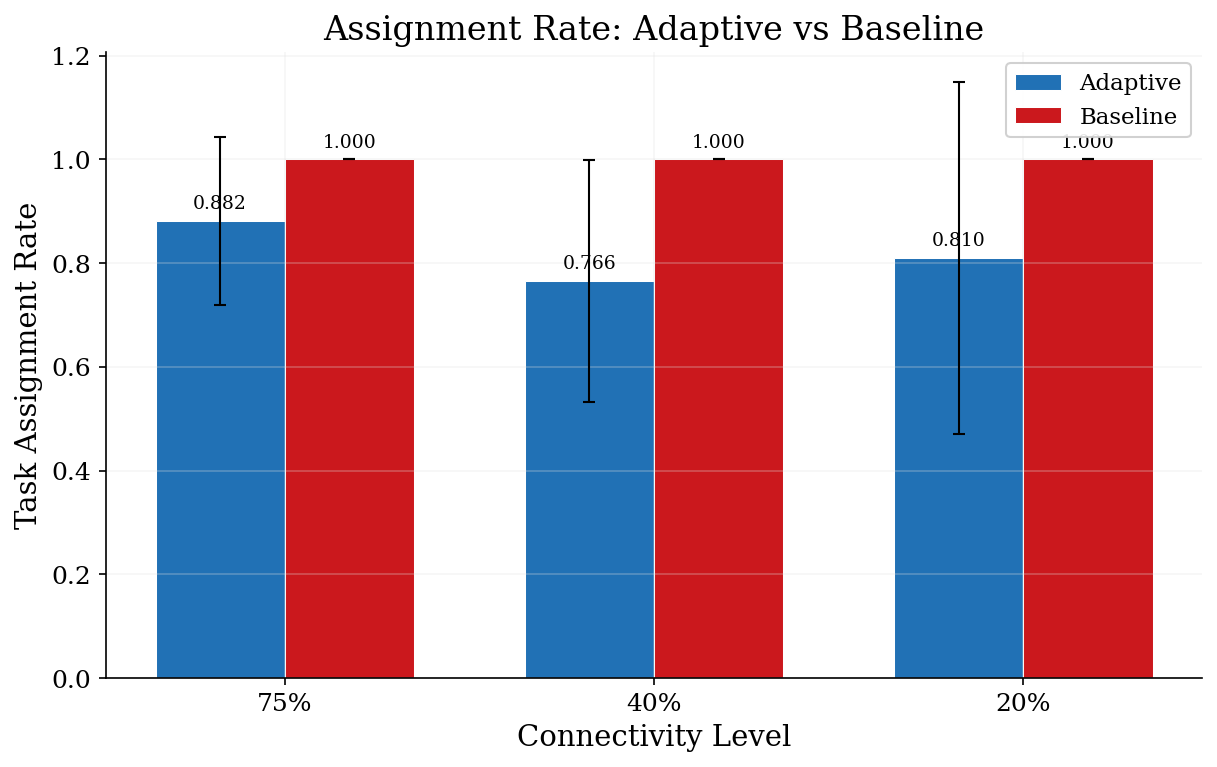

In [8]:
# Figure 2: Assignment Rate — Grouped Bar Chart
fig = plot_grouped_bars(summaries["assignment_rate"], "assignment_rate")
save_figure(fig, "fig_assignment_rate_bars", FIGURES_DIR)
plt.show()

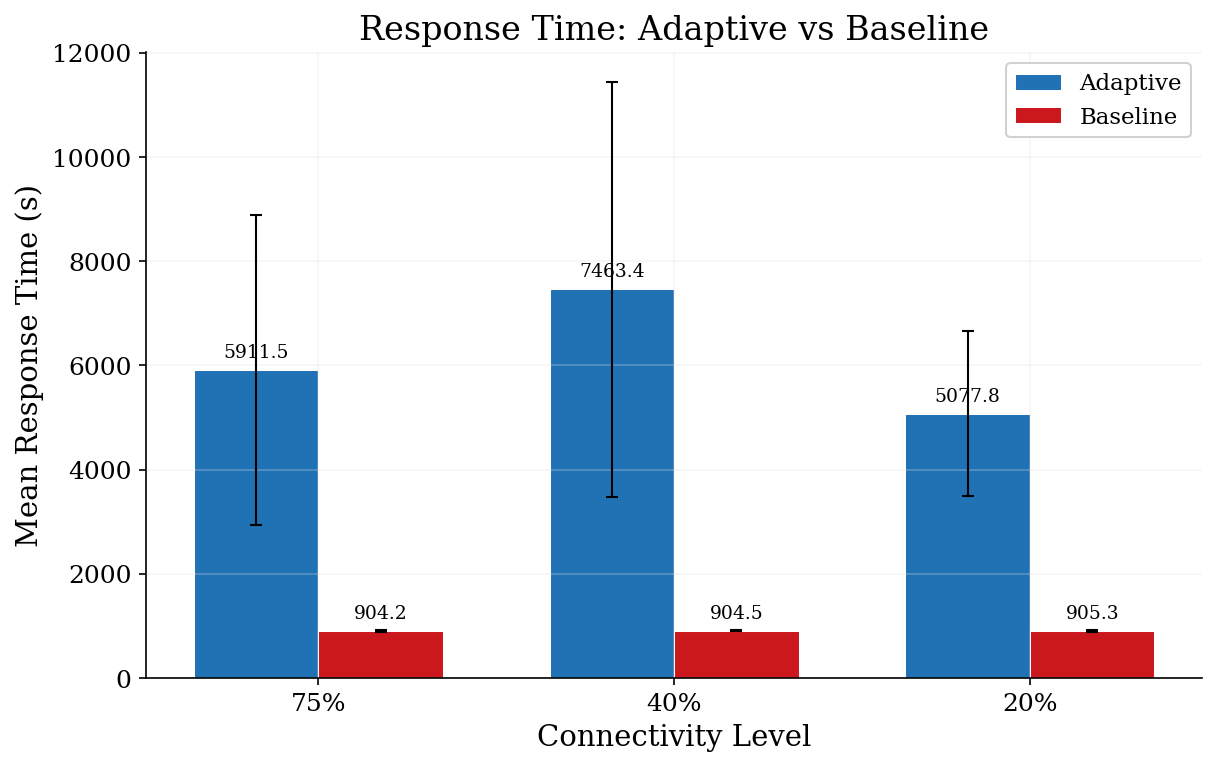

In [9]:
# Figure 3: Response Time — Grouped Bar Chart
fig = plot_grouped_bars(summaries["avg_response_time"], "avg_response_time")
save_figure(fig, "fig_response_time_bars", FIGURES_DIR)
plt.show()

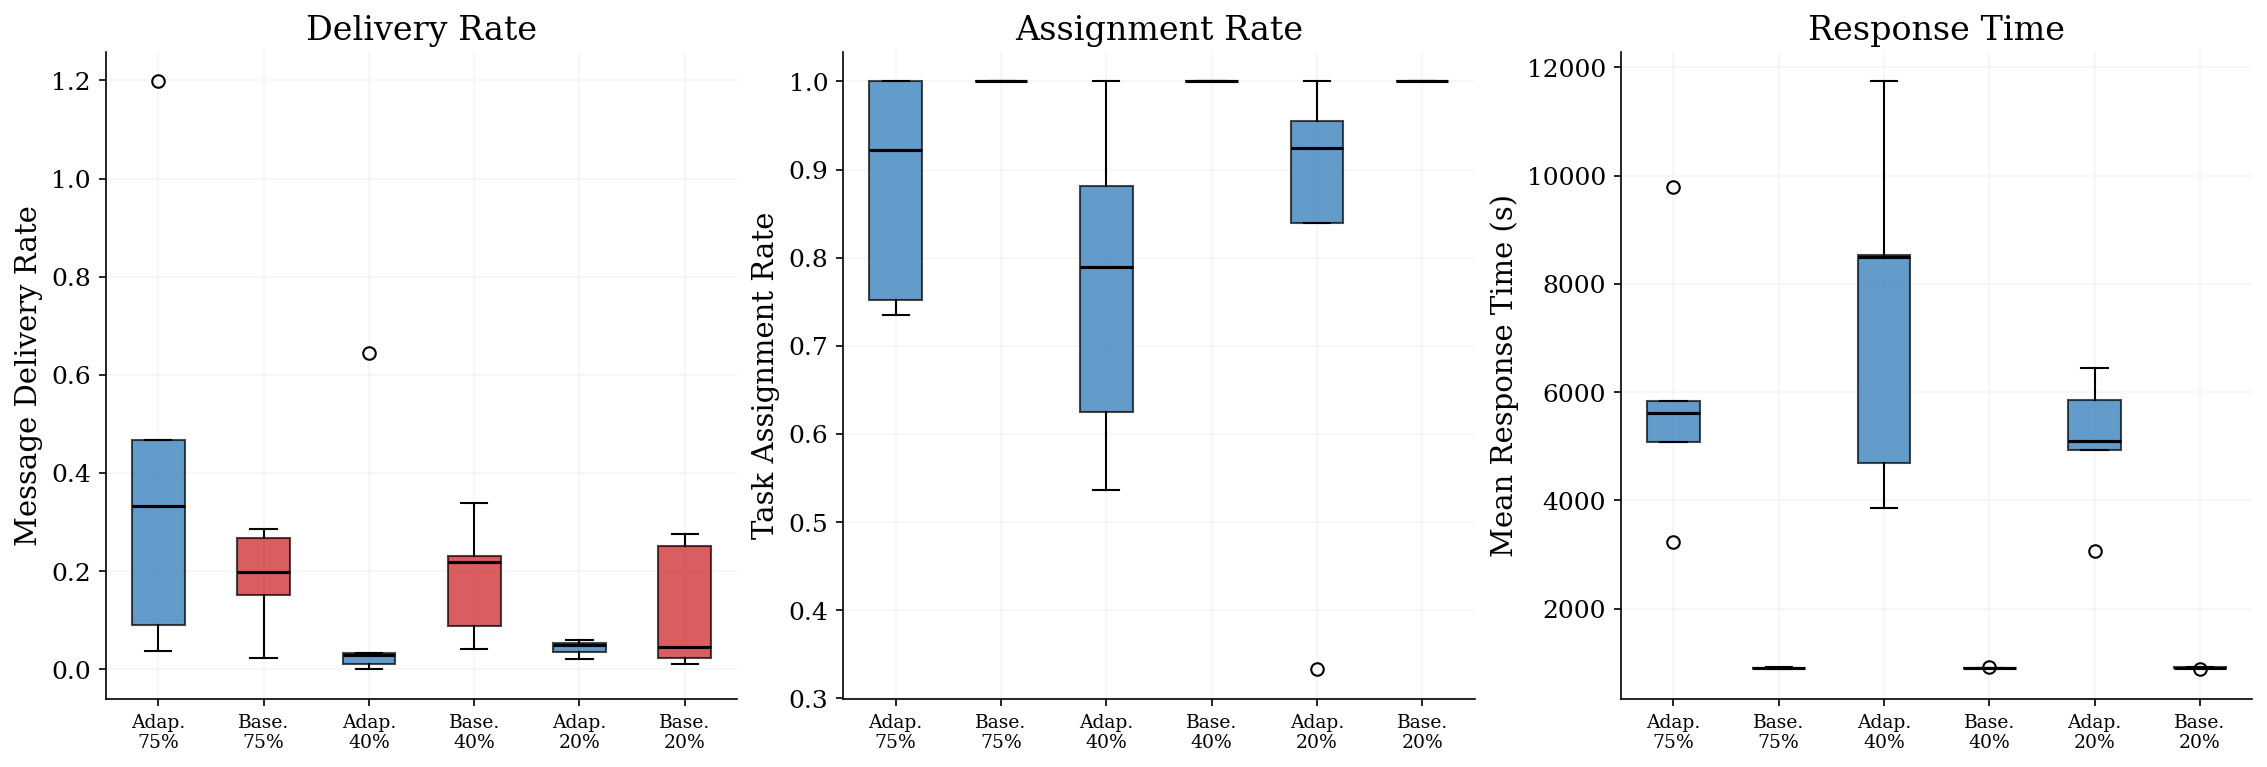

In [10]:
# Figure 4: Box Plot Distributions
fig = plot_box_distributions(df)
save_figure(fig, "fig_box_distributions", FIGURES_DIR)
plt.show()

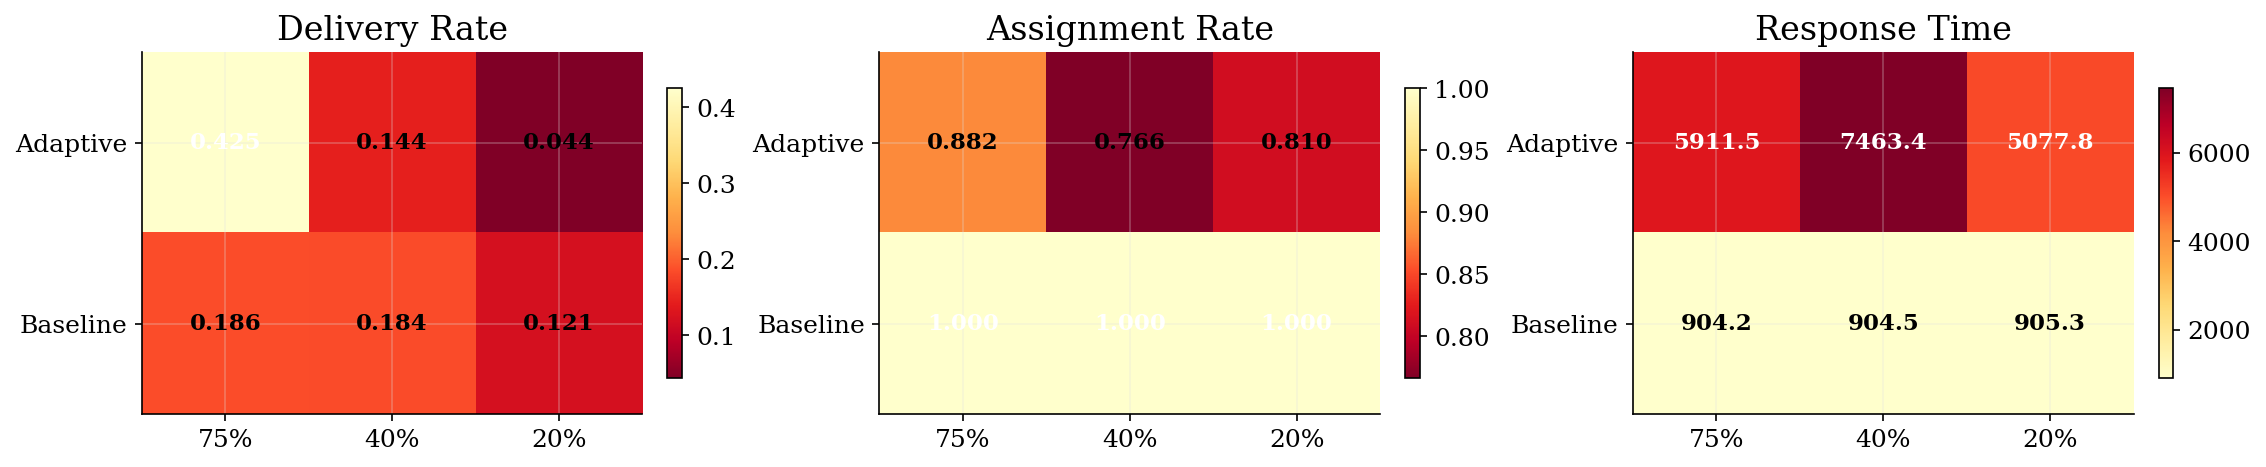

In [11]:
# Figure 5: Performance Heatmap
fig = plot_heatmap(df)
save_figure(fig, "fig_heatmap", FIGURES_DIR)
plt.show()

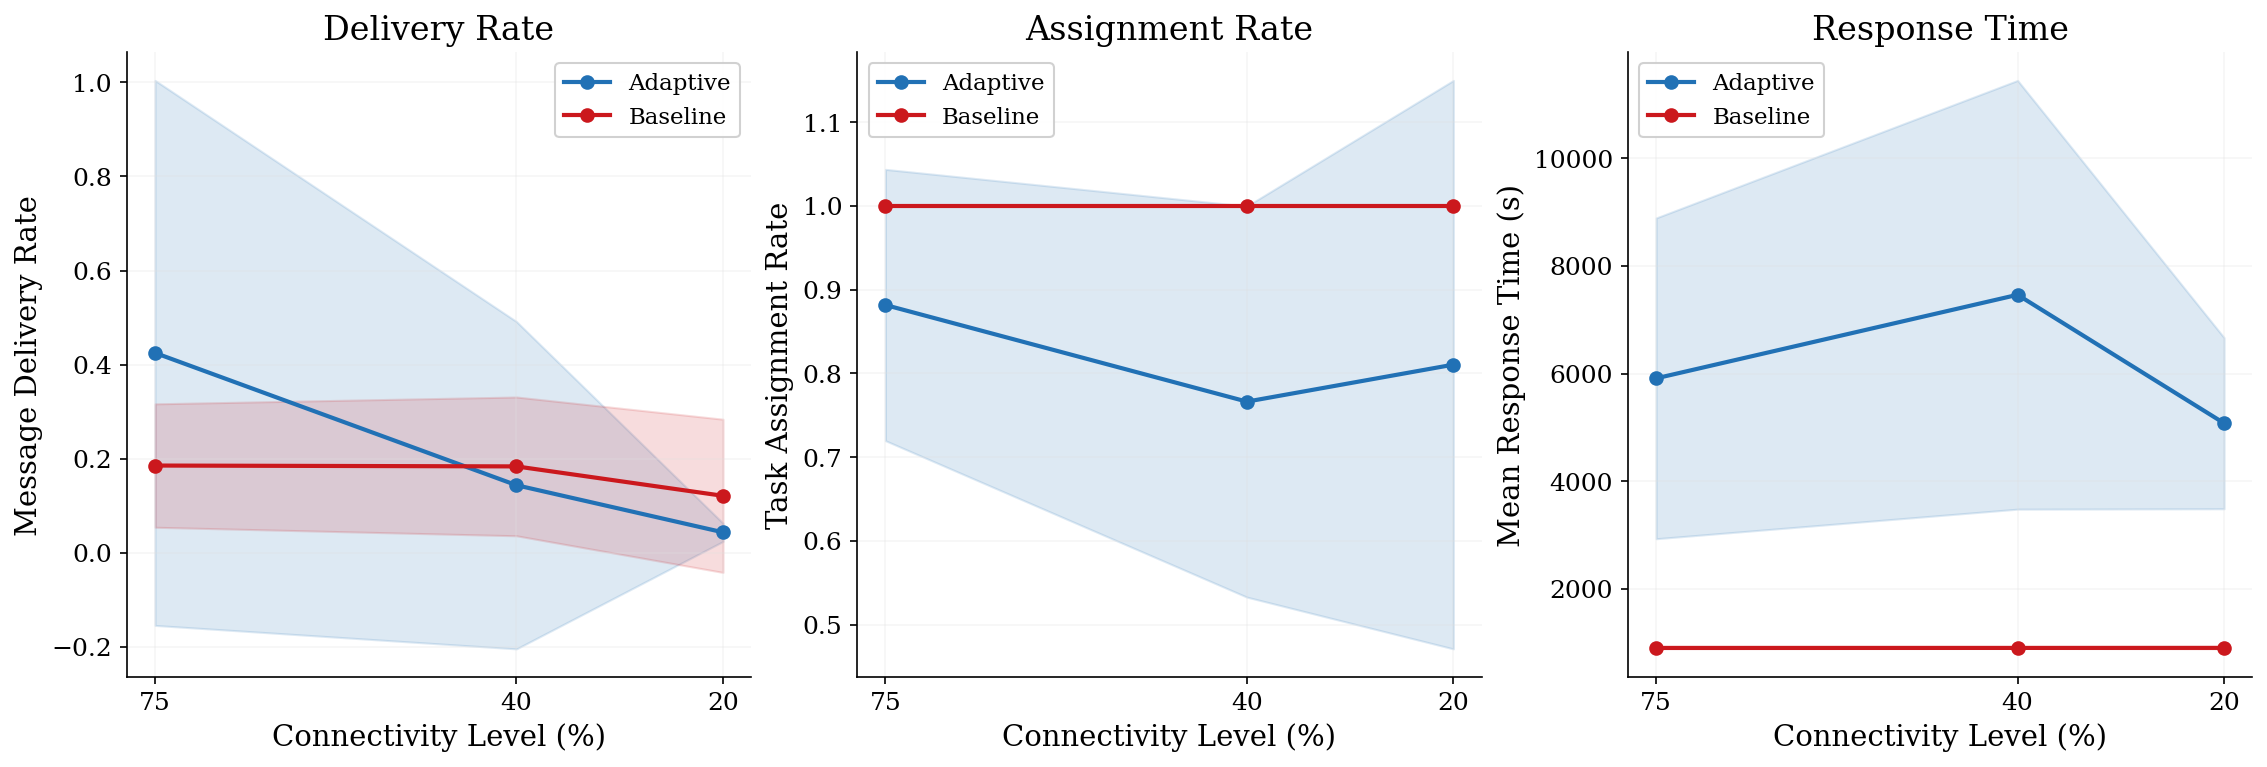

In [12]:
# Figure 6: Connectivity Degradation Lines
fig = plot_degradation_lines(summaries)
save_figure(fig, "fig_degradation_lines", FIGURES_DIR)
plt.show()

In [13]:
# Summary of saved figures
figure_files = sorted(FIGURES_DIR.glob("fig_*.png"))
print(f"\nGenerated {len(figure_files)} figures in {FIGURES_DIR}:")
for f in figure_files:
    print(f"  {f.name}")


Generated 6 figures in /Users/dianafonseca/resilient-emergency-response/outputs/figures:
  fig_assignment_rate_bars.png
  fig_box_distributions.png
  fig_degradation_lines.png
  fig_delivery_rate_bars.png
  fig_heatmap.png
  fig_response_time_bars.png


## 4. Statistical Analysis

Comparing algorithms using Welch's t-test (per connectivity level) and
one-way ANOVA (across connectivity levels). Significance level: \u03b1 = 0.05.

In [14]:
evaluator = PerformanceEvaluator(results)
report = evaluator.generate_report(
    metrics=[MetricType.DELIVERY_RATE, MetricType.ASSIGNMENT_RATE, MetricType.RESPONSE_TIME]
)

/Users/dianafonseca/resilient-emergency-response/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [15]:
# Table 1: Welch's t-test Results
ttest_df = build_ttest_table(report)
display(
    ttest_df.style
    .set_caption("Table 1: Welch's t-test Results (Adaptive vs Baseline)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Connectivity,Adaptive (mean ± std),Baseline (mean ± std),Improvement,t,p-value,Cohen's d,Sig.
Delivery Rate,Overall,0.2042 ± 0.3355,0.1636 ± 0.1144,+24.82%,0.444,0.6628,0.162,No
Delivery Rate,20%,0.0437 ± 0.0156,0.1213 ± 0.1311,-63.95%,-1.313,0.2576,-0.831,No
Delivery Rate,40%,0.1438 ± 0.2801,0.1838 ± 0.1188,-21.76%,-0.294,0.7798,-0.186,No
Delivery Rate,75%,0.4250 ± 0.4665,0.1856 ± 0.1056,+128.95%,1.119,0.3203,0.708,No
Assignment Rate,Overall,0.8195 ± 0.1967,1.0000 ± 0.0000,-18.05%,-3.554,0.0032,-1.298,Yes
Assignment Rate,20%,0.8105 ± 0.2732,1.0000 ± 0.0000,-18.95%,-1.551,0.1959,-0.981,No
Assignment Rate,40%,0.7663 ± 0.1879,1.0000 ± 0.0000,-23.37%,-2.780,0.0498,-1.758,Yes
Assignment Rate,75%,0.8817 ± 0.1304,1.0000 ± 0.0000,-11.83%,-2.029,0.1123,-1.283,No
Response Time,Overall,6150.9142 ± 2469.1684,904.6594 ± 10.9364,+579.91%,8.229,0.0000,3.005,Yes
Response Time,20%,5077.8369 ± 1279.4469,905.2560 ± 14.7335,+460.93%,7.292,0.0019,4.612,Yes


In [16]:
# Table 2: ANOVA Results
anova_df = build_anova_table(report)
display(
    anova_df.style
    .set_caption("Table 2: One-way ANOVA Results (Effect of Connectivity)")
    .hide(axis="index")
    .map(lambda v: "font-weight: bold; background-color: #d4edda" if v == "Yes" else "", subset=["Sig."])
)

Metric,Algorithm,F,p-value,df,η²,Effect,Sig.
Delivery Rate,Adaptive,1.978,0.1809,"(2, 12)",0.248,large,No
Delivery Rate,Baseline,0.474,0.6336,"(2, 12)",0.073,medium,No
Assignment Rate,Adaptive,0.400,0.6790,"(2, 12)",0.062,medium,No
Assignment Rate,Baseline,nan,nan,"(2, 12)",0.000,negligible,No
Response Time,Adaptive,1.244,0.3229,"(2, 12)",0.172,large,No
Response Time,Baseline,0.010,0.9899,"(2, 12)",0.002,negligible,No


In [17]:
# Effect Size Interpretation
print("Effect Size Interpretation")
print("=" * 65)
for comp in report.comparisons:
    d = abs(comp.ttest.cohens_d)
    if d < 0.2:
        size = "negligible"
    elif d < 0.5:
        size = "small"
    elif d < 0.8:
        size = "medium"
    else:
        size = "large"
    if comp.connectivity_level is not None:
        label = f"{comp.metric.value} @ {comp.connectivity_level * 100:.0f}%"
    else:
        label = f"{comp.metric.value} (overall)"
    sig = "*" if comp.ttest.significant else ""
    print(f"  {label:40s}  d = {comp.ttest.cohens_d:+.3f} ({size}){sig}")

Effect Size Interpretation
  delivery_rate (overall)                   d = +0.162 (negligible)
  delivery_rate @ 20%                       d = -0.831 (large)
  delivery_rate @ 40%                       d = -0.186 (negligible)
  delivery_rate @ 75%                       d = +0.708 (medium)
  assignment_rate (overall)                 d = -1.298 (large)*
  assignment_rate @ 20%                     d = -0.981 (large)
  assignment_rate @ 40%                     d = -1.758 (large)*
  assignment_rate @ 75%                     d = -1.283 (large)
  response_time (overall)                   d = +3.005 (large)*
  response_time @ 20%                       d = +4.612 (large)*
  response_time @ 40%                       d = +2.893 (large)*
  response_time @ 75%                       d = +2.952 (large)*


## 5. Key Findings

In [18]:
print("KEY FINDINGS")
print("=" * 60)

# 1. Overall delivery rate
overall_dr = next(
    (c for c in report.comparisons
     if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is None),
    None,
)
if overall_dr:
    print(f"\n1. DELIVERY RATE (Overall)")
    print(f"   Adaptive: {overall_dr.adaptive_stats.mean:.4f} +/- {overall_dr.adaptive_stats.std:.4f}")
    print(f"   Baseline: {overall_dr.baseline_stats.mean:.4f} +/- {overall_dr.baseline_stats.std:.4f}")
    print(f"   Improvement: {overall_dr.improvement:+.2f}%")
    print(f"   Significant: {'Yes' if overall_dr.ttest.significant else 'No'} (p={overall_dr.ttest.p_value:.4f})")

# 2. Where advantage is largest
per_conn = [
    c for c in report.comparisons
    if c.metric == MetricType.DELIVERY_RATE and c.connectivity_level is not None
]
if per_conn:
    best = max(per_conn, key=lambda c: c.improvement)
    print(f"\n2. LARGEST ADAPTIVE ADVANTAGE")
    print(f"   At {best.connectivity_level * 100:.0f}% connectivity: {best.improvement:+.2f}% improvement")

# 3. Connectivity effect
print(f"\n3. CONNECTIVITY EFFECT (ANOVA)")
for key, anova in report.anova_results.items():
    parts = key.rsplit("_", 1)
    metric_name = parts[0].replace("_", " ").title()
    algorithm = parts[1].capitalize() if len(parts) > 1 else "All"
    print(
        f"   {metric_name} ({algorithm}): "
        f"F({anova.df_between},{anova.df_within}) = {anova.f_statistic:.3f}, "
        f"p = {anova.p_value:.4f}, \u03b7\u00b2 = {anova.eta_squared:.3f}"
    )

print("\n" + "=" * 60)
print(f"Experiment complete. All figures saved to: {FIGURES_DIR}")

KEY FINDINGS

1. DELIVERY RATE (Overall)
   Adaptive: 0.2042 +/- 0.3355
   Baseline: 0.1636 +/- 0.1144
   Improvement: +24.82%
   Significant: No (p=0.6628)

2. LARGEST ADAPTIVE ADVANTAGE
   At 75% connectivity: +128.95% improvement

3. CONNECTIVITY EFFECT (ANOVA)
   Delivery Rate (Adaptive): F(2,12) = 1.978, p = 0.1809, η² = 0.248
   Delivery Rate (Baseline): F(2,12) = 0.474, p = 0.6336, η² = 0.073
   Assignment Rate (Adaptive): F(2,12) = 0.400, p = 0.6790, η² = 0.062
   Assignment Rate (Baseline): F(2,12) = nan, p = nan, η² = 0.000
   Response Time (Adaptive): F(2,12) = 1.244, p = 0.3229, η² = 0.172
   Response Time (Baseline): F(2,12) = 0.010, p = 0.9899, η² = 0.002

Experiment complete. All figures saved to: /Users/dianafonseca/resilient-emergency-response/outputs/figures
